In [1]:
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torch.optim import lr_scheduler
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    # Plot Loss Curve
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    # Plot Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.title("Accuracy Curve")

    # Display the plots
    plt.tight_layout()
    plt.show()

In [3]:
def plot_confusion_matrix(model, test_loader, class_names):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    # Get predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot confusion matrix using seaborn heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()




In [21]:
def train_and_evaluate(model, train_loader, test_loader, criterion, epochs, device, scheduler = '', lr = 0.001):
    best_val_accuracy = 0.0  # Initialize the best validation accuracy
    best_model_state_dict = None  # This will store the best model's state dict
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    if scheduler == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
    elif scheduler == "ExponentialLR":
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1)
    
    for epoch in range(epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        total = 0
        correct = 0

        # Training loop
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Update the weights
            optimizer.step()
            
            if scheduler != '':
                scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Record training loss and accuracy
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Print the average loss for this epoch
        # print(f"\nEpoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

        # Now, evaluate the model on the test set after every epoch
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():  # Disable gradient computation during evaluation
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Get predicted class
                _, predicted = torch.max(outputs, 1)

                # Count correct predictions
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(test_loader)
        val_accuracy = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
              
        # Save the model if it has the best validation accuracy so far
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy  # Save the state dict of the best model
            torch.save(model , 'best_model.pth')  # Save the best model's weights
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}% * Model saved")  
            # print(f"* Model saved with new best validation accuracy: {val_accuracy:.2f}%")
        else:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")  
            
    # After training, load the best model weights
    model = torch.load('best_model.pth')
        
    plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)
    plot_confusion_matrix(model, test_loader, classes) # of best model

In [5]:
# If final evaluation of the model is needed after the training process is complete
def evaluate_model(model, test_loader, criterion):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for images, labels in test_loader:
            # Move data to GPU if available
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Get the predictions
            _, predicted = torch.max(outputs, 1)

            # Calculate accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate the average loss and accuracy
    avg_loss = running_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy


In [38]:
def grid_search(param_grid, device, epochs=10):
    best_accuracy = 0.0
    best_params = {}

    # Generate all combinations of parameters in the grid
    for params in ParameterGrid(param_grid):
        print(f"Training with parameters: {params}")

        # Create DataLoader for the current batch size
        model = SignModelGridSearch(hidden_size_1=params['hidden_size_1'], hidden_size_2=params['hidden_size_2'])
        model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = Adam(model.parameters(), lr=0.001)

        # Train the model
        for epoch in range(epochs):
            model.train()  # Set the model to training mode        
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)        
                optimizer.zero_grad() # Zero the gradients        
                outputs = model(inputs) # Forward pass        
                loss = criterion(outputs, labels) # Compute loss        
                loss.backward() # Backward pass        
                optimizer.step() # Update the weights
        
        _, accuracy = evaluate_model(model, test_loader, criterion)

        # Update the best model if necessary
        if accuracy > best_accuracy:
            best_params = params
            best_accuracy = accuracy

    # Return the best model and parameters
    return best_params, best_accuracy

In [58]:
def k_fold_cross_validation(model, dataset, device, k=5, epochs=10):
    kfold = KFold(n_splits=k, shuffle=True)
    best_accuracy = 0.0
    best_params = {}
    best_model = None
    fold_accuracies = []
    fold_avg_accuracy = 0.0

    # Perform K-fold cross-validation
    for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset)):

        # Split dataset into training and validation sets
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset = torch.utils.data.Subset(dataset, val_idx)
        
        # Create DataLoader for training and validation sets
        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

        # Create model, criterion, and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = Adam(model.parameters(), lr=0.001)

        # Train and evaluate the model for this fold
        train_and_evaluate(model, train_loader, val_loader, criterion, epochs, device)
        _, fold_accuracy = evaluate_model(model, test_loader, criterion)
        fold_avg_accuracy += fold_accuracy  # Accumulate the accuracy for this fold

        print(f"Fold {fold+1} validation accuracy: {fold_accuracy:.2f}%")

    # Average the accuracy across all folds
    fold_avg_accuracy /= k
    print(f"Average validation accuracy for this parameter set: {fold_avg_accuracy:.2f}%")

    # Update the best model if necessary
    if fold_avg_accuracy > best_accuracy:
        best_accuracy = fold_avg_accuracy

    # Return the best model and parameters
    return best_accuracy

In [8]:
# Define your directories
train_dir = 'original_trafic_sign/train'
test_dir = 'original_trafic_sign/test'

#train_dir = 'flowers/train'
#test_dir = 'flowers/test'

data_augmentation = transforms.Compose([
    transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))], p=1.0),  # Random Translation
    transforms.RandomApply([transforms.ColorJitter(contrast=0.1)], p=1.0),  # Random Contrast
    transforms.RandomApply([transforms.RandomResizedCrop(128, scale=(0.9, 1.0))], p=1.0),  # Random Zoom (using crop)
])

# Define your transformations (resize, tensor conversion, normalization)
data_transform = transforms.Compose([
    data_augmentation, 
    transforms.Resize((128, 128)),              # Resize images to 128x128
    transforms.ToTensor(),                      # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

# Load the datasets using ImageFolder
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

# Create DataLoaders for batching
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# train_data.classes, train_data.class_to_idx
classes = set(train_data.classes)
num_classes = len(train_data.classes)
num_classes

12

# Network Architectures

In [9]:
# Define the PyTorch model using Sequential
class SignModel(nn.Module):
    def __init__(self):
        super(SignModel, self).__init__()
        
        # Build the model using Sequential
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Dropout after convolutional layers
            nn.Dropout(0.5),
            
            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, 256),  # Assuming input images are 128x128
            nn.ReLU(),
            nn.Dropout(0.6),

            # Fully connected Layer 2
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output layer
            nn.Linear(128, num_classes)  
        )

    def forward(self, x):
        return self.model(x)

In [10]:
class SignModelBatchNorm(nn.Module):
    def __init__(self):
        super(SignModelBatchNorm, self).__init__()
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling + Batch Normalization
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.BatchNorm2d(16),  # Batch Normalization
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling + Batch Normalization
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),  # Batch Normalization
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling + Batch Normalization
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),  # Batch Normalization
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling + Batch Normalization
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),  # Batch Normalization
            nn.MaxPool2d(2, 2),

            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, 256),  # Assuming input images are 128x128
            nn.ReLU(),

            # Fully connected Layer 2
            nn.Linear(256, 128),
            nn.ReLU(),

            # Output layer
            nn.Linear(128, num_classes)  # 3 classes (left, right, straight)
        )

    def forward(self, x):
        return self.model(x)

In [36]:
# Define the PyTorch model using Sequential
class SignModelGridSearch(nn.Module):
    def __init__(self, hidden_size_1=256, hidden_size_2=128):
        super(SignModelGridSearch, self).__init__()
        
        # Build the model using Sequential
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Dropout after convolutional layers
            nn.Dropout(0.5),
            
            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, hidden_size_1),  # Assuming input images are 128x128
            nn.ReLU(),
            nn.Dropout(0.6),

            # Fully connected Layer 2
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output layer
            nn.Linear(hidden_size_2, num_classes)  # 3 classes (left, right, straight)
        )

    def forward(self, x):
        return self.model(x)

In [30]:
# Define the PyTorch model using Sequential
class SignModelGridSearch1(nn.Module):
    def __init__(self, hidden_size_1=256, hidden_size_2=128, hidden_size_3 = 64):
        super(SignModelGridSearch1, self).__init__()
        
        # Build the model using Sequential
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Dropout after convolutional layers
            nn.Dropout(0.5),
            
            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, hidden_size_1),  # Assuming input images are 128x128
            nn.ReLU(),
            nn.Dropout(0.6),

            # Fully connected Layer 2
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(hidden_size_2, hidden_size_3),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Output layer
            nn.Linear(hidden_size_3, num_classes)  # 3 classes (left, right, straight)
        )

    def forward(self, x):
        return self.model(x)

In [23]:
# Instantiate the model
model = SignModel().to(device)
model_BatchNorm = SignModelBatchNorm().to(device)

criterion = nn.CrossEntropyLoss()  # Equivalent to sparse_categorical_crossentropy


In [60]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Train model with dropout

Epoch 1/200 - Train Loss: 2.3760, Train Acc: 45.89% | Val Loss: 2.3465, Val Acc: 47.21%
* Model saved with new best validation accuracy: 47.21%
Epoch 2/200 - Train Loss: 2.1861, Train Acc: 48.06% | Val Loss: 2.2073, Val Acc: 47.21%
Epoch 3/200 - Train Loss: 2.0278, Train Acc: 48.89% | Val Loss: 2.0558, Val Acc: 50.87%
* Model saved with new best validation accuracy: 50.87%
Epoch 4/200 - Train Loss: 1.8661, Train Acc: 52.49% | Val Loss: 1.8555, Val Acc: 51.64%
* Model saved with new best validation accuracy: 51.64%
Epoch 5/200 - Train Loss: 1.6843, Train Acc: 55.49% | Val Loss: 1.7144, Val Acc: 56.84%
* Model saved with new best validation accuracy: 56.84%
Epoch 6/200 - Train Loss: 1.5365, Train Acc: 59.43% | Val Loss: 1.5831, Val Acc: 59.54%
* Model saved with new best validation accuracy: 59.54%
Epoch 7/200 - Train Loss: 1.3564, Train Acc: 63.47% | Val Loss: 1.4272, Val Acc: 63.58%
* Model saved with new best validation accuracy: 63.58%
Epoch 8/200 - Train Loss: 1.2819, Train Acc: 63.

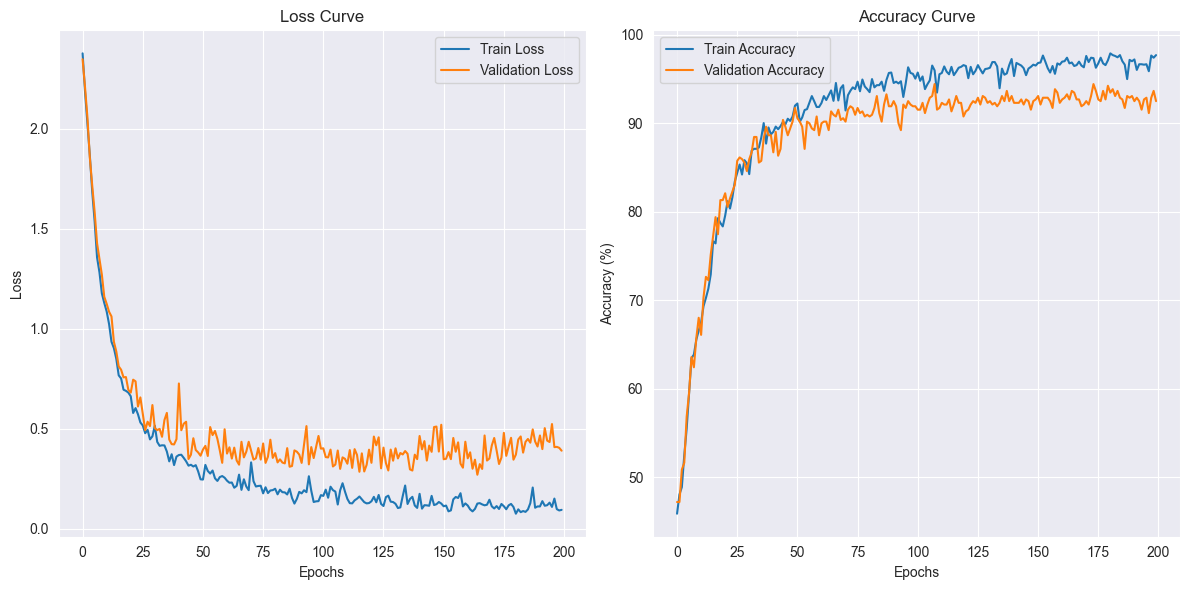

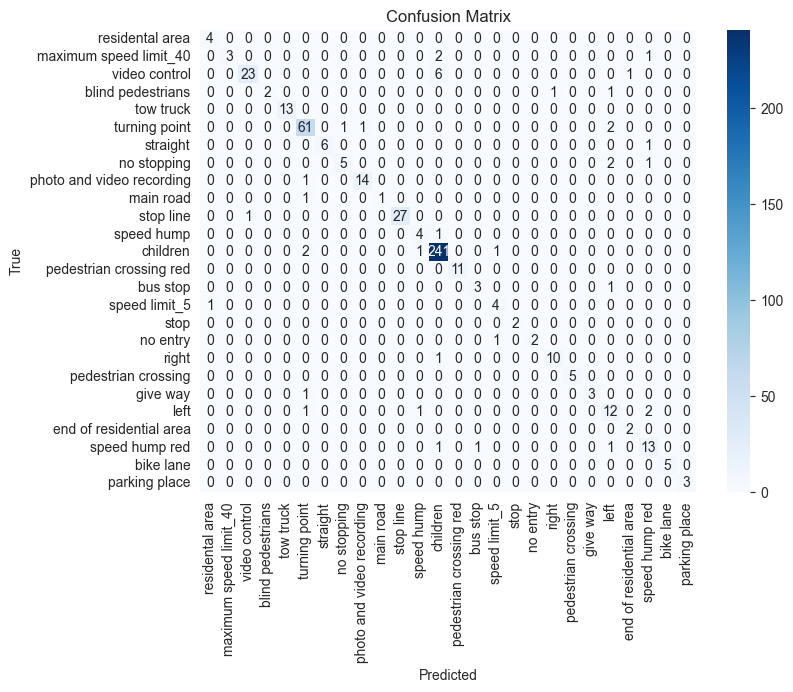

In [16]:
train_and_evaluate(model, train_loader, test_loader, criterion, 200, device)

In [17]:
evaluate_model(model, test_loader, criterion)

Test Loss: 0.4582, Test Accuracy: 92.29%


(0.45818887406037717, 92.29287090558766)

Epoch 1/100 - Train Loss: 2.4210, Train Acc: 13.66% | Val Loss: 2.3376, Val Acc: 21.84% * Model saved
Epoch 2/100 - Train Loss: 2.2715, Train Acc: 20.54% | Val Loss: 1.9246, Val Acc: 28.06% * Model saved
Epoch 3/100 - Train Loss: 1.8619, Train Acc: 32.27% | Val Loss: 1.3866, Val Acc: 51.50% * Model saved
Epoch 4/100 - Train Loss: 1.4014, Train Acc: 48.66% | Val Loss: 1.1855, Val Acc: 58.72% * Model saved
Epoch 5/100 - Train Loss: 1.2320, Train Acc: 53.67% | Val Loss: 0.9816, Val Acc: 64.13% * Model saved
Epoch 6/100 - Train Loss: 1.0844, Train Acc: 59.43% | Val Loss: 0.8983, Val Acc: 64.13%
Epoch 7/100 - Train Loss: 0.9774, Train Acc: 63.58% | Val Loss: 0.7730, Val Acc: 72.14% * Model saved
Epoch 8/100 - Train Loss: 0.8597, Train Acc: 67.63% | Val Loss: 0.6916, Val Acc: 79.36% * Model saved
Epoch 9/100 - Train Loss: 0.7939, Train Acc: 71.37% | Val Loss: 0.6061, Val Acc: 78.96%
Epoch 10/100 - Train Loss: 0.7499, Train Acc: 73.75% | Val Loss: 0.5764, Val Acc: 83.77% * Model saved
Epoch 1

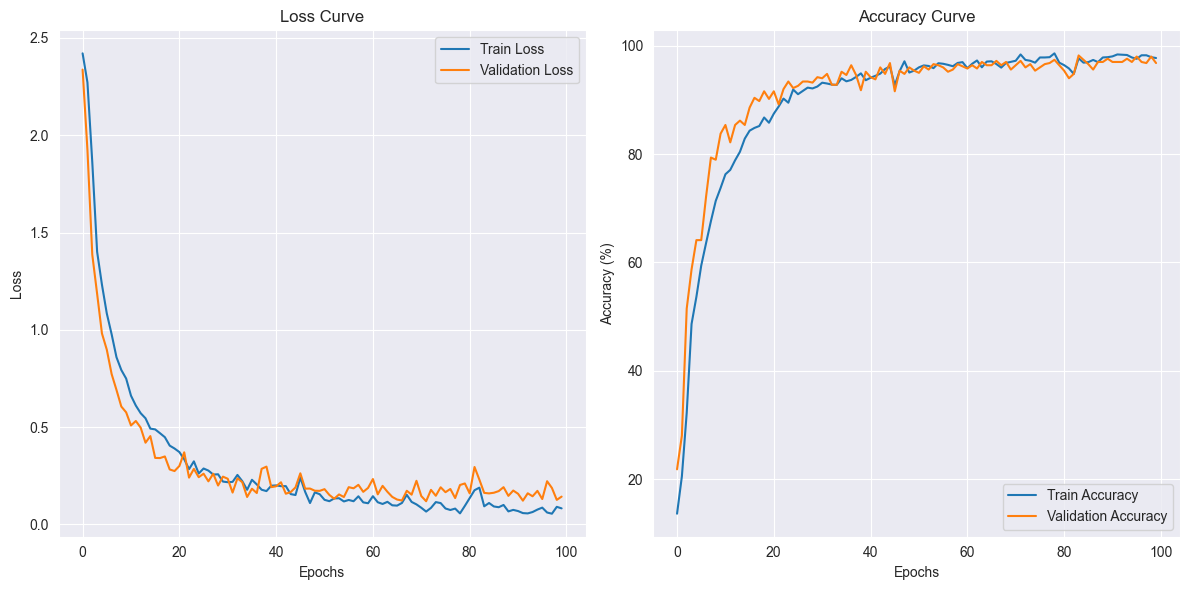

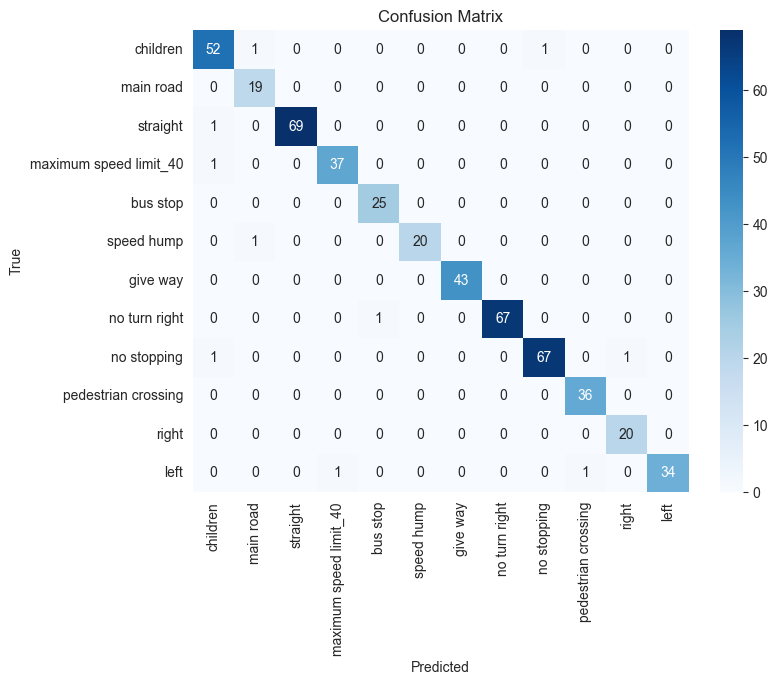

In [25]:
train_and_evaluate(model, train_loader, test_loader, criterion, 100, device)

In [26]:
train_and_evaluate(model, train_loader, test_loader, criterion, 50, device)

Epoch 1/50 - Train Loss: 0.0957, Train Acc: 97.82% | Val Loss: 0.1899, Val Acc: 96.99% * Model saved
Epoch 2/50 - Train Loss: 0.1477, Train Acc: 97.12% | Val Loss: 0.1667, Val Acc: 97.39% * Model saved
Epoch 3/50 - Train Loss: 0.0726, Train Acc: 98.43% | Val Loss: 0.1553, Val Acc: 97.80% * Model saved
Epoch 4/50 - Train Loss: 0.0796, Train Acc: 97.98% | Val Loss: 0.1838, Val Acc: 97.39%
Epoch 5/50 - Train Loss: 0.0943, Train Acc: 97.82% | Val Loss: 0.1878, Val Acc: 96.79%
Epoch 6/50 - Train Loss: 0.0944, Train Acc: 97.67% | Val Loss: 0.2301, Val Acc: 96.59%
Epoch 7/50 - Train Loss: 0.0748, Train Acc: 97.93% | Val Loss: 0.2429, Val Acc: 96.59%
Epoch 8/50 - Train Loss: 0.0913, Train Acc: 97.67% | Val Loss: 0.2432, Val Acc: 96.59%
Epoch 9/50 - Train Loss: 0.0873, Train Acc: 98.38% | Val Loss: 0.2125, Val Acc: 96.99%
Epoch 10/50 - Train Loss: 0.0579, Train Acc: 98.18% | Val Loss: 0.1590, Val Acc: 96.99%


KeyboardInterrupt: 

In [28]:
best_model = torch.load('best_model.pth')
evaluate_model(best_model, test_loader, criterion)

Test Loss: 0.1840, Test Accuracy: 97.80%


(0.1839647698070621, 97.79559118236473)

# Train model with Batch Normalization

In [16]:
train_and_evaluate(model_BatchNorm, train_loader, test_loader, criterion, 100, device)


Epoch [1/100], Loss: 0.9998
Epoch 1/100 - Train Loss: 0.9998, Train Acc: 52.31% | Val Loss: 1.1944, Val Acc: 35.44%

Epoch [2/100], Loss: 0.5671
Epoch 2/100 - Train Loss: 0.5671, Train Acc: 78.47% | Val Loss: 1.0813, Val Acc: 51.90%

Epoch [3/100], Loss: 0.4340
Epoch 3/100 - Train Loss: 0.4340, Train Acc: 81.71% | Val Loss: 0.8898, Val Acc: 60.76%

Epoch [4/100], Loss: 0.3437
Epoch 4/100 - Train Loss: 0.3437, Train Acc: 84.95% | Val Loss: 1.0806, Val Acc: 54.43%

Epoch [5/100], Loss: 0.3269
Epoch 5/100 - Train Loss: 0.3269, Train Acc: 88.43% | Val Loss: 0.9456, Val Acc: 58.23%

Epoch [6/100], Loss: 0.2293
Epoch 6/100 - Train Loss: 0.2293, Train Acc: 91.44% | Val Loss: 1.9185, Val Acc: 53.16%

Epoch [7/100], Loss: 0.1482
Epoch 7/100 - Train Loss: 0.1482, Train Acc: 94.21% | Val Loss: 1.4420, Val Acc: 58.23%

Epoch [8/100], Loss: 0.1590
Epoch 8/100 - Train Loss: 0.1590, Train Acc: 94.21% | Val Loss: 1.2671, Val Acc: 64.56%

Epoch [9/100], Loss: 0.1787
Epoch 9/100 - Train Loss: 0.1787, T

72.15189873417721

In [17]:
evaluate_model(model_BatchNorm, test_loader, criterion)

Test Loss: 0.5130, Test Accuracy: 91.14%


(0.5130190189617375, 91.13924050632912)

так как модель с dropout показала лучше результат далее использовала его

Since the model with dropout demonstrated better performance, it was decided to continue using it.


# Train model with StepLR

попробовала StepLR с Adam выдал 26% accuracy.StepLR с SGD выдал 34% accuracy

The StepLR scheduler with the Adam optimizer achieved an accuracy of 26%, while the combination of StepLR with the SGD optimizer resulted in an accuracy of 34%.


In [15]:
model = SignModel().to(device)
train_and_evaluate(model, train_loader, test_loader, criterion, 100, device, "StepLR")


Epoch [1/100], Loss: 1.0988
Epoch 1/100 - Train Loss: 1.0988, Train Acc: 33.33% | Val Loss: 1.0824, Val Acc: 34.18%

Epoch [2/100], Loss: 1.1014
Epoch 2/100 - Train Loss: 1.1014, Train Acc: 33.33% | Val Loss: 1.0823, Val Acc: 34.18%

Epoch [3/100], Loss: 1.1016
Epoch 3/100 - Train Loss: 1.1016, Train Acc: 33.33% | Val Loss: 1.0824, Val Acc: 34.18%

Epoch [4/100], Loss: 1.1015
Epoch 4/100 - Train Loss: 1.1015, Train Acc: 33.33% | Val Loss: 1.0825, Val Acc: 34.18%

Epoch [5/100], Loss: 1.0996
Epoch 5/100 - Train Loss: 1.0996, Train Acc: 33.33% | Val Loss: 1.0827, Val Acc: 34.18%

Epoch [6/100], Loss: 1.1003
Epoch 6/100 - Train Loss: 1.1003, Train Acc: 33.33% | Val Loss: 1.0824, Val Acc: 34.18%

Epoch [7/100], Loss: 1.1015
Epoch 7/100 - Train Loss: 1.1015, Train Acc: 33.33% | Val Loss: 1.0827, Val Acc: 34.18%

Epoch [8/100], Loss: 1.1013
Epoch 8/100 - Train Loss: 1.1013, Train Acc: 33.33% | Val Loss: 1.0824, Val Acc: 34.18%

Epoch [9/100], Loss: 1.1005
Epoch 9/100 - Train Loss: 1.1005, T

KeyboardInterrupt: 

In [19]:
evaluate_model(model, test_loader, criterion)

Test Loss: 1.0993, Test Accuracy: 26.58%


(1.099331259727478, 26.582278481012658)

# Train model with ExponentialLR

попробовала ExponentialLR с Adam выдал 34% accuracy.ExponentialLR с SGD выдал 34% accuracy

The ExponentialLR scheduler with the Adam optimizer achieved an accuracy of 34%, while the combination of ExponentialLR with the SGD optimizer also resulted in an accuracy of 34%.

In [16]:
model = SignModel().to(device)
train_and_evaluate(model, train_loader, test_loader, criterion, 100, device, "ExponentialLR")


Epoch [1/100], Loss: 1.0986
Epoch 1/100 - Train Loss: 1.0986, Train Acc: 35.19% | Val Loss: 1.1014, Val Acc: 30.38%

Epoch [2/100], Loss: 1.0987
Epoch 2/100 - Train Loss: 1.0987, Train Acc: 33.56% | Val Loss: 1.1014, Val Acc: 32.91%

Epoch [3/100], Loss: 1.1007
Epoch 3/100 - Train Loss: 1.1007, Train Acc: 31.94% | Val Loss: 1.1010, Val Acc: 31.65%

Epoch [4/100], Loss: 1.1009
Epoch 4/100 - Train Loss: 1.1009, Train Acc: 30.09% | Val Loss: 1.1013, Val Acc: 32.91%

Epoch [5/100], Loss: 1.0998
Epoch 5/100 - Train Loss: 1.0998, Train Acc: 33.33% | Val Loss: 1.1012, Val Acc: 32.91%

Epoch [6/100], Loss: 1.1003
Epoch 6/100 - Train Loss: 1.1003, Train Acc: 32.18% | Val Loss: 1.1012, Val Acc: 30.38%

Epoch [7/100], Loss: 1.0995
Epoch 7/100 - Train Loss: 1.0995, Train Acc: 31.25% | Val Loss: 1.1008, Val Acc: 34.18%

Epoch [8/100], Loss: 1.1003
Epoch 8/100 - Train Loss: 1.1003, Train Acc: 32.18% | Val Loss: 1.1011, Val Acc: 31.65%

Epoch [9/100], Loss: 1.0988
Epoch 9/100 - Train Loss: 1.0988, T

KeyboardInterrupt: 

In [21]:
evaluate_model(model, test_loader, criterion)


Test Loss: 1.0898, Test Accuracy: 34.18%


(1.0898452599843342, 34.177215189873415)

так как learning rate scheduler выдавал намного меньше accuracy

After conducting a series of experiments with different learning rate schedulers and optimizers, it was found that the use of a scheduler resulted in significantly worse performance compared to training without it. Consequently, it was decided to exclude the scheduler from the model.

# Grid Search

In [40]:
param_grid = {
    'hidden_size_1': [512, 256, 64],
    'hidden_size_2': [512, 256, 64, 32]
}

# Запуск Grid Search
best_params, best_accuracy = grid_search(param_grid, device, 10)

print(f"Best model hyperparameters: {best_params} with accuracy {best_accuracy}")

Training with parameters: {'hidden_size_1': 512, 'hidden_size_2': 512}
Test Loss: 0.4672, Test Accuracy: 84.17%
Training with parameters: {'hidden_size_1': 512, 'hidden_size_2': 256}
Test Loss: 0.5107, Test Accuracy: 84.57%
Training with parameters: {'hidden_size_1': 512, 'hidden_size_2': 64}
Test Loss: 0.6213, Test Accuracy: 79.16%
Training with parameters: {'hidden_size_1': 512, 'hidden_size_2': 32}
Test Loss: 0.7090, Test Accuracy: 75.55%
Training with parameters: {'hidden_size_1': 256, 'hidden_size_2': 512}
Test Loss: 0.5933, Test Accuracy: 80.96%
Training with parameters: {'hidden_size_1': 256, 'hidden_size_2': 256}
Test Loss: 0.4955, Test Accuracy: 82.97%
Training with parameters: {'hidden_size_1': 256, 'hidden_size_2': 64}
Test Loss: 0.6840, Test Accuracy: 76.75%
Training with parameters: {'hidden_size_1': 256, 'hidden_size_2': 32}
Test Loss: 0.7220, Test Accuracy: 74.95%
Training with parameters: {'hidden_size_1': 64, 'hidden_size_2': 512}
Test Loss: 0.8623, Test Accuracy: 67.7

In [43]:
param_grid = {
    'hidden_size_1': [8192, 4096, 2048, 1024, 512, 256],
    'hidden_size_2': [8192, 4096, 2048, 1024, 512, 256]
}

# Запуск Grid Search
best_params, best_accuracy = grid_search(param_grid, device, 10)

print(f"Best model hyperparameters: {best_params} with accuracy {best_accuracy}")

Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 8192}
Test Loss: 0.4700, Test Accuracy: 87.98%
Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 4096}
Test Loss: 0.4123, Test Accuracy: 85.97%
Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 2048}
Test Loss: 0.3985, Test Accuracy: 88.58%
Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 1024}
Test Loss: 0.3735, Test Accuracy: 89.18%
Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 512}
Test Loss: 0.4450, Test Accuracy: 84.77%
Training with parameters: {'hidden_size_1': 8192, 'hidden_size_2': 256}
Test Loss: 0.4271, Test Accuracy: 84.77%
Training with parameters: {'hidden_size_1': 4096, 'hidden_size_2': 8192}
Test Loss: 0.4418, Test Accuracy: 85.37%
Training with parameters: {'hidden_size_1': 4096, 'hidden_size_2': 4096}
Test Loss: 0.4180, Test Accuracy: 85.57%
Training with parameters: {'hidden_size_1': 4096, 'hidden_size_2': 2048}
Test Loss: 0.3532

# Updated model with best hyperparameters

In [48]:
# Define the PyTorch model using Sequential
class SignModelUpgraded(nn.Module):
    def __init__(self):
        super(SignModelUpgraded, self).__init__()
        
        # Build the model using Sequential
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Dropout after convolutional layers
            nn.Dropout(0.5),
            
            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, best_params['hidden_size_1']),  # Assuming input images are 128x128
            nn.ReLU(),
            nn.Dropout(0.6),

            # Fully connected Layer 2
            nn.Linear(best_params['hidden_size_1'], best_params['hidden_size_2']),
            nn.ReLU(),
            nn.Dropout(0.5),
            

            # Output layer
            nn.Linear(best_params['hidden_size_2'], num_classes)  # 3 classes (left, right, straight)
        )

    def forward(self, x):
        return self.model(x)
    
model = SignModelUpgraded().to(device)
criterion = nn.CrossEntropyLoss()
# Define optimizer and loss function


In [52]:
# Define the PyTorch model using Sequential
class SignModelUpgraded1(nn.Module):
    def __init__(self):
        super(SignModelUpgraded1, self).__init__()
        
        # Build the model using Sequential
        self.model = nn.Sequential(
            # Convolutional Layer 1 + MaxPooling
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # Conv Layer
            nn.ReLU(),  # Activation
            nn.MaxPool2d(2, 2),  # MaxPooling

            # Convolutional Layer 2 + MaxPooling
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 3 + MaxPooling
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolutional Layer 4 + MaxPooling
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Dropout after convolutional layers
            nn.Dropout(0.5),
            
            # Flatten the output for fully connected layers
            nn.Flatten(),

            # Fully connected Layer 1
            nn.Linear(128 * 8 * 8, 2048),  # Assuming input images are 128x128
            nn.ReLU(),
            nn.Dropout(0.6),

            # Fully connected Layer 2
            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # nn.Linear(256, 512),
            # nn.ReLU(),
            # nn.Dropout(0.5),

            # Output layer
            nn.Linear(2048, num_classes) 
        )

    def forward(self, x):
        return self.model(x)
    
model1 = SignModelUpgraded1().to(device)
criterion = nn.CrossEntropyLoss()
# Define optimizer and loss function


Epoch 1/100 - Train Loss: 2.3738, Train Acc: 16.29% | Val Loss: 2.1056, Val Acc: 31.46% * Model saved
Epoch 2/100 - Train Loss: 1.8359, Train Acc: 34.95% | Val Loss: 1.4733, Val Acc: 44.49% * Model saved
Epoch 3/100 - Train Loss: 1.3349, Train Acc: 53.67% | Val Loss: 1.0294, Val Acc: 62.93% * Model saved
Epoch 4/100 - Train Loss: 0.9898, Train Acc: 64.44% | Val Loss: 0.7706, Val Acc: 73.15% * Model saved
Epoch 5/100 - Train Loss: 0.8352, Train Acc: 70.61% | Val Loss: 0.6603, Val Acc: 73.55% * Model saved
Epoch 6/100 - Train Loss: 0.7130, Train Acc: 75.16% | Val Loss: 0.5622, Val Acc: 80.96% * Model saved
Epoch 7/100 - Train Loss: 0.5955, Train Acc: 79.97% | Val Loss: 0.4765, Val Acc: 85.17% * Model saved
Epoch 8/100 - Train Loss: 0.5187, Train Acc: 82.35% | Val Loss: 0.4423, Val Acc: 86.97% * Model saved
Epoch 9/100 - Train Loss: 0.4765, Train Acc: 83.76% | Val Loss: 0.3654, Val Acc: 89.18% * Model saved
Epoch 10/100 - Train Loss: 0.4507, Train Acc: 85.58% | Val Loss: 0.3656, Val Acc: 

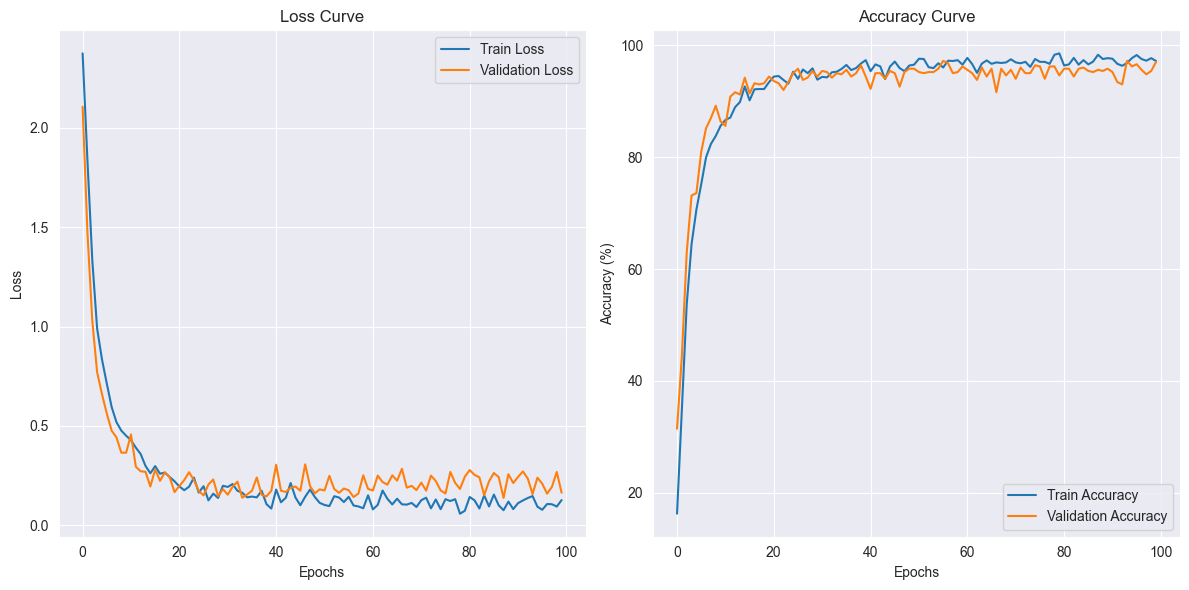

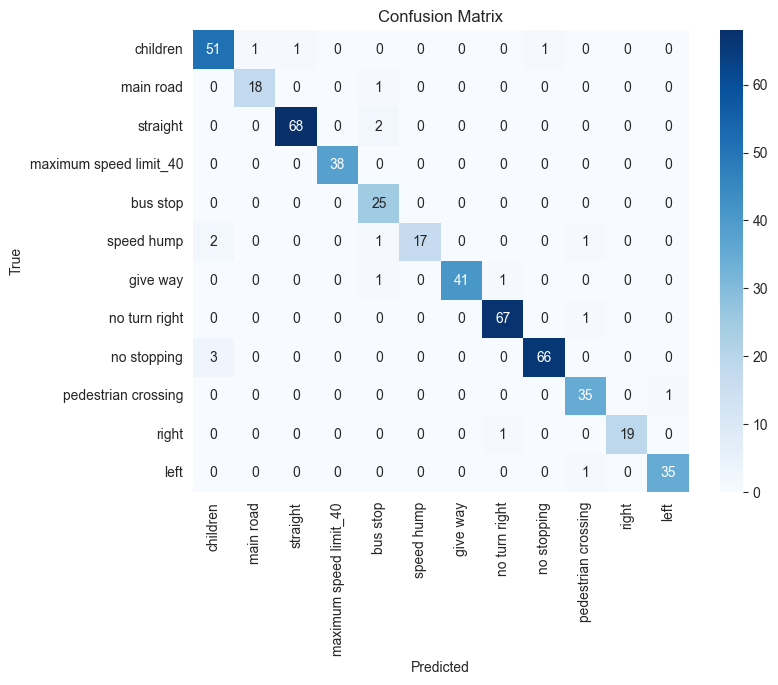

In [49]:
train_and_evaluate(model, train_loader, test_loader, criterion, 100, device)

In [50]:
evaluate_model(model, test_loader, criterion)

Test Loss: 0.1492, Test Accuracy: 95.99%


(0.14923022104721895, 95.99198396793587)

Epoch 1/100 - Train Loss: 2.3218, Train Acc: 20.89% | Val Loss: 1.9201, Val Acc: 32.87% * Model saved
Epoch 2/100 - Train Loss: 1.5726, Train Acc: 44.06% | Val Loss: 1.2471, Val Acc: 54.11% * Model saved
Epoch 3/100 - Train Loss: 1.1361, Train Acc: 59.13% | Val Loss: 0.9170, Val Acc: 71.14% * Model saved
Epoch 4/100 - Train Loss: 0.8848, Train Acc: 69.55% | Val Loss: 0.6986, Val Acc: 77.96% * Model saved
Epoch 5/100 - Train Loss: 0.6931, Train Acc: 75.57% | Val Loss: 0.6408, Val Acc: 80.56% * Model saved
Epoch 6/100 - Train Loss: 0.5665, Train Acc: 80.78% | Val Loss: 0.5080, Val Acc: 84.77% * Model saved
Epoch 7/100 - Train Loss: 0.5149, Train Acc: 81.44% | Val Loss: 0.4252, Val Acc: 85.17% * Model saved
Epoch 8/100 - Train Loss: 0.4411, Train Acc: 85.03% | Val Loss: 0.4068, Val Acc: 86.17% * Model saved
Epoch 9/100 - Train Loss: 0.4148, Train Acc: 85.94% | Val Loss: 0.3511, Val Acc: 86.97% * Model saved
Epoch 10/100 - Train Loss: 0.4008, Train Acc: 87.30% | Val Loss: 0.2967, Val Acc: 

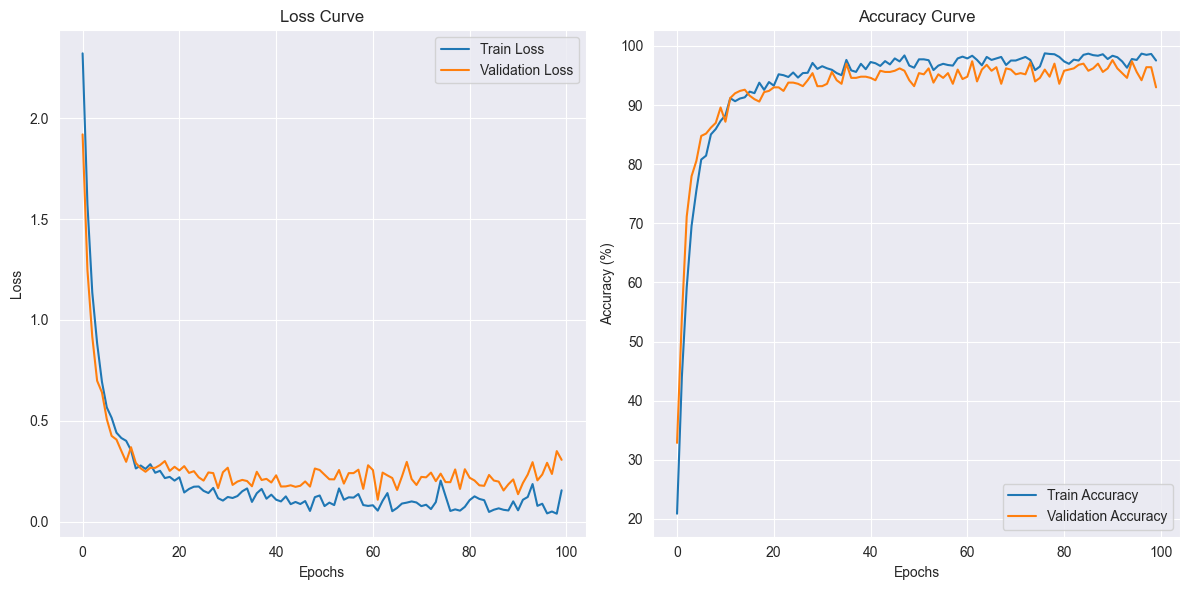

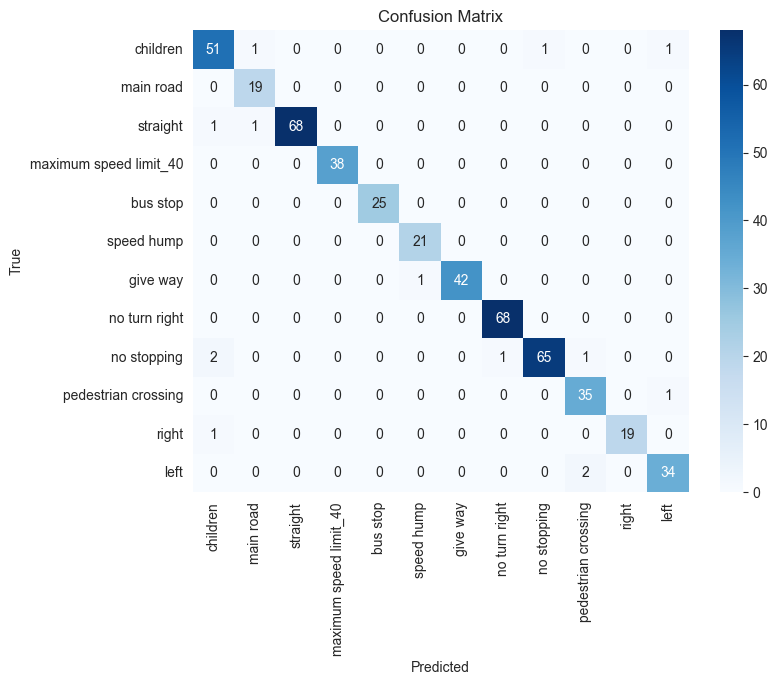

In [54]:
train_and_evaluate(model1, train_loader, test_loader, criterion, 100, device)

In [55]:
evaluate_model(model1, test_loader, criterion)

Test Loss: 0.2947, Test Accuracy: 93.99%


(0.2947366153821349, 93.9879759519038)

# Cross-validation

Epoch 1/100 - Train Loss: 2.4373, Train Acc: 12.08% | Val Loss: 2.4040, Val Acc: 13.13% * Model saved
Epoch 2/100 - Train Loss: 2.3204, Train Acc: 19.23% | Val Loss: 2.0793, Val Acc: 25.25% * Model saved
Epoch 3/100 - Train Loss: 1.9057, Train Acc: 31.82% | Val Loss: 1.5238, Val Acc: 46.72% * Model saved
Epoch 4/100 - Train Loss: 1.4724, Train Acc: 46.74% | Val Loss: 1.1570, Val Acc: 55.56% * Model saved
Epoch 5/100 - Train Loss: 1.2531, Train Acc: 53.95% | Val Loss: 1.0212, Val Acc: 64.39% * Model saved
Epoch 6/100 - Train Loss: 1.0977, Train Acc: 58.06% | Val Loss: 0.8951, Val Acc: 67.68% * Model saved
Epoch 7/100 - Train Loss: 0.9823, Train Acc: 63.50% | Val Loss: 0.7948, Val Acc: 69.95% * Model saved
Epoch 8/100 - Train Loss: 0.8689, Train Acc: 68.69% | Val Loss: 0.7598, Val Acc: 70.45% * Model saved
Epoch 9/100 - Train Loss: 0.8352, Train Acc: 68.88% | Val Loss: 0.7268, Val Acc: 70.20%
Epoch 10/100 - Train Loss: 0.7946, Train Acc: 70.27% | Val Loss: 0.6079, Val Acc: 75.25% * Model

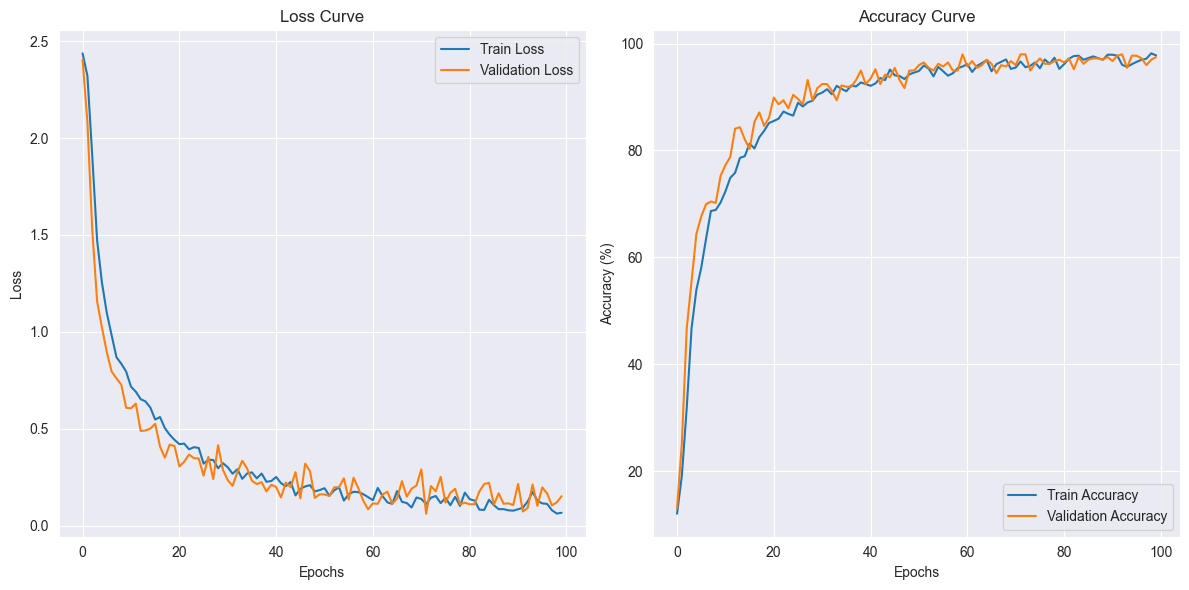

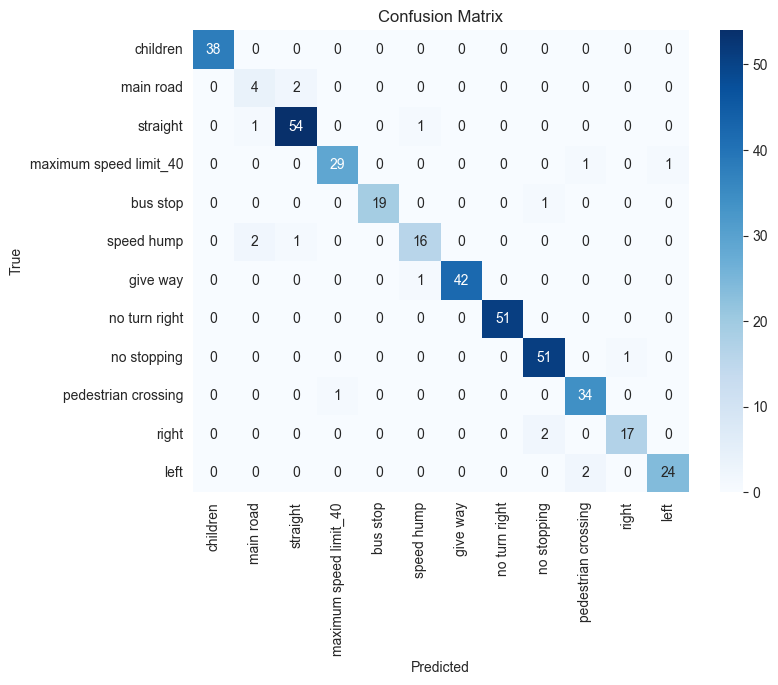

Test Loss: 0.2668, Test Accuracy: 95.79%
Fold 1 validation accuracy: 95.79%
Epoch 1/100 - Train Loss: 0.1361, Train Acc: 97.03% | Val Loss: 0.0664, Val Acc: 98.99% * Model saved
Epoch 2/100 - Train Loss: 0.1346, Train Acc: 96.71% | Val Loss: 0.0042, Val Acc: 100.00% * Model saved
Epoch 3/100 - Train Loss: 0.1343, Train Acc: 96.90% | Val Loss: 0.0268, Val Acc: 99.24%
Epoch 4/100 - Train Loss: 0.1681, Train Acc: 95.70% | Val Loss: 0.0261, Val Acc: 98.99%
Epoch 5/100 - Train Loss: 0.0818, Train Acc: 97.98% | Val Loss: 0.0166, Val Acc: 99.75%
Epoch 6/100 - Train Loss: 0.0959, Train Acc: 97.53% | Val Loss: 0.0148, Val Acc: 99.24%
Epoch 7/100 - Train Loss: 0.1283, Train Acc: 96.96% | Val Loss: 0.0207, Val Acc: 99.24%
Epoch 8/100 - Train Loss: 0.0907, Train Acc: 97.66% | Val Loss: 0.0244, Val Acc: 99.49%
Epoch 9/100 - Train Loss: 0.1226, Train Acc: 96.65% | Val Loss: 0.0533, Val Acc: 97.98%
Epoch 10/100 - Train Loss: 0.0997, Train Acc: 96.77% | Val Loss: 0.0287, Val Acc: 98.99%
Epoch 11/100 -

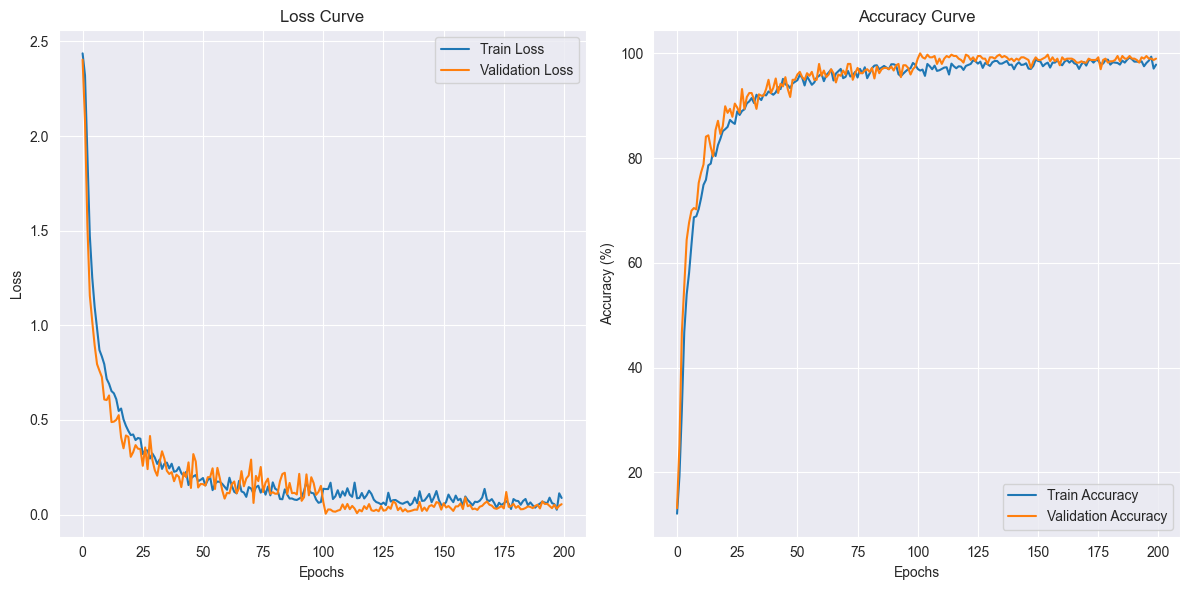

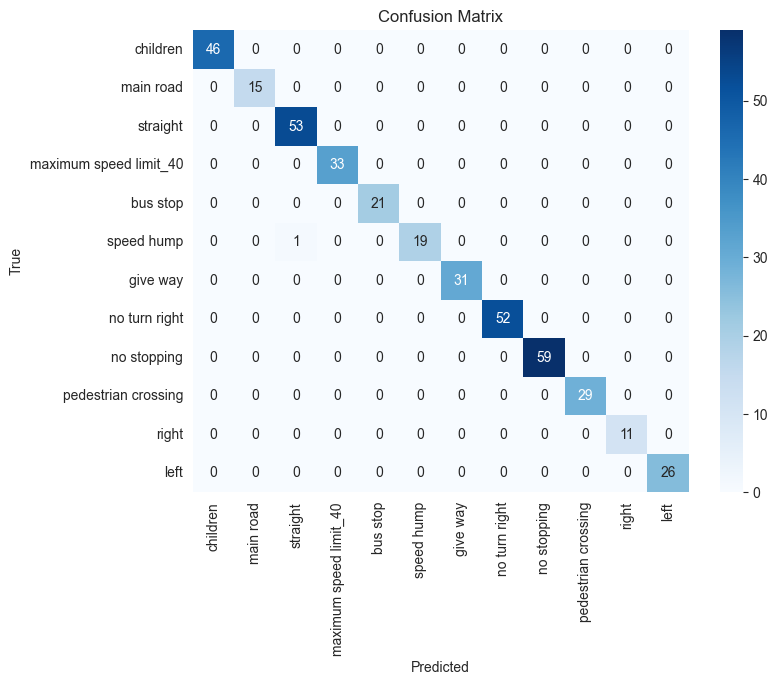

Test Loss: 0.2597, Test Accuracy: 96.59%
Fold 2 validation accuracy: 96.59%
Epoch 1/100 - Train Loss: 0.0886, Train Acc: 97.60% | Val Loss: 0.0693, Val Acc: 98.73% * Model saved
Epoch 2/100 - Train Loss: 0.0876, Train Acc: 98.42% | Val Loss: 0.0749, Val Acc: 99.75% * Model saved
Epoch 3/100 - Train Loss: 0.0996, Train Acc: 97.72% | Val Loss: 0.0043, Val Acc: 100.00% * Model saved
Epoch 4/100 - Train Loss: 0.0591, Train Acc: 98.23% | Val Loss: 0.0070, Val Acc: 99.75%
Epoch 5/100 - Train Loss: 0.0666, Train Acc: 98.23% | Val Loss: 0.0103, Val Acc: 99.49%
Epoch 6/100 - Train Loss: 0.0610, Train Acc: 98.36% | Val Loss: 0.0459, Val Acc: 99.49%
Epoch 7/100 - Train Loss: 0.0446, Train Acc: 98.93% | Val Loss: 0.0092, Val Acc: 99.75%
Epoch 8/100 - Train Loss: 0.1415, Train Acc: 97.16% | Val Loss: 0.0070, Val Acc: 100.00%
Epoch 9/100 - Train Loss: 0.0934, Train Acc: 98.48% | Val Loss: 0.0035, Val Acc: 99.75%
Epoch 10/100 - Train Loss: 0.0672, Train Acc: 98.29% | Val Loss: 0.0220, Val Acc: 99.49%

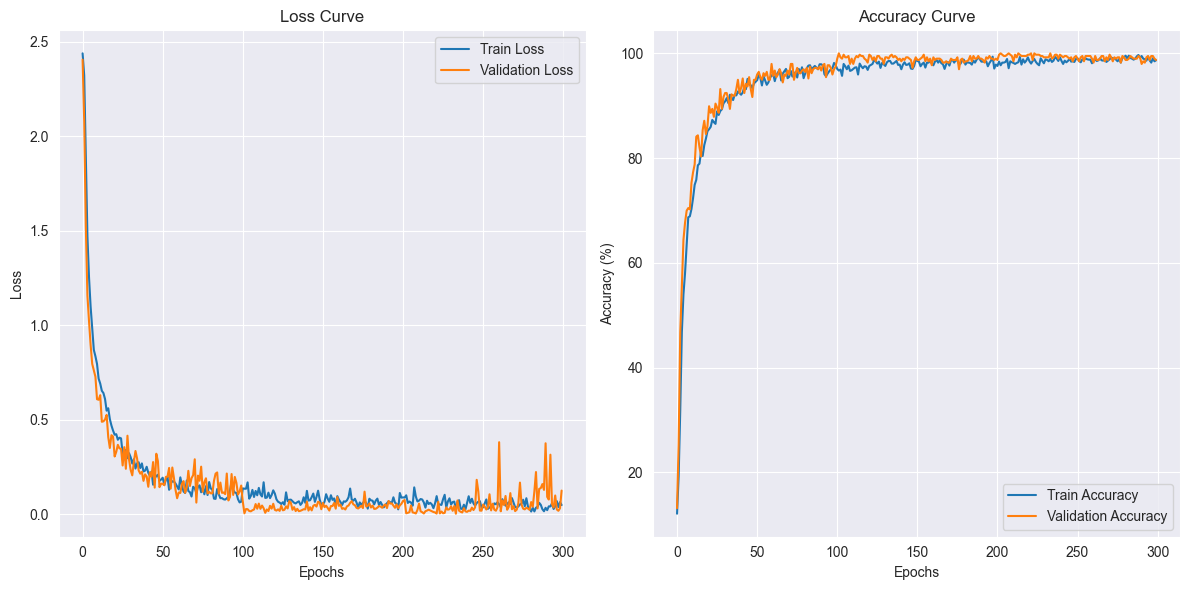

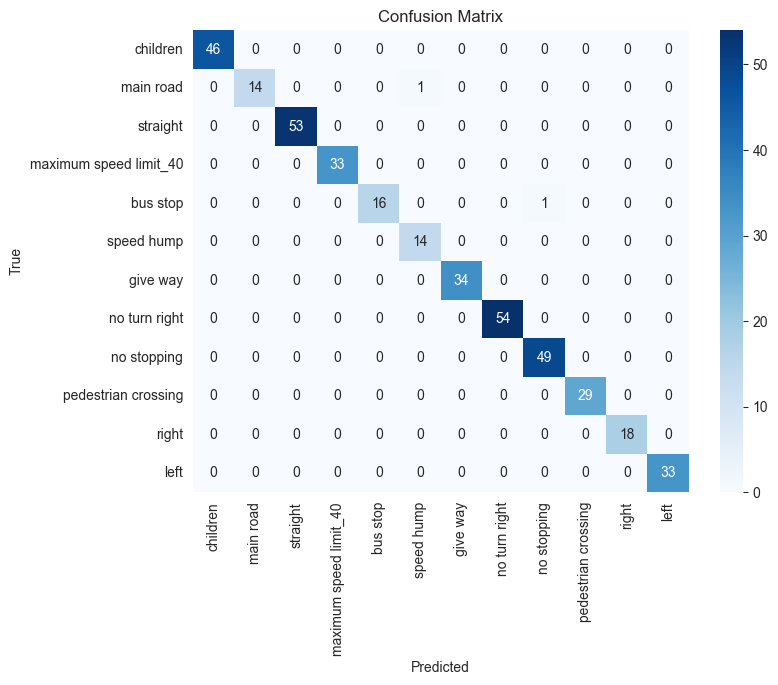

Test Loss: 0.1530, Test Accuracy: 97.80%
Fold 3 validation accuracy: 97.80%
Epoch 1/100 - Train Loss: 0.0916, Train Acc: 98.36% | Val Loss: 0.0016, Val Acc: 100.00% * Model saved
Epoch 2/100 - Train Loss: 0.0714, Train Acc: 98.67% | Val Loss: 0.0773, Val Acc: 99.49%
Epoch 3/100 - Train Loss: 0.0979, Train Acc: 98.67% | Val Loss: 0.0012, Val Acc: 100.00%
Epoch 4/100 - Train Loss: 0.0623, Train Acc: 98.61% | Val Loss: 0.0537, Val Acc: 99.24%
Epoch 5/100 - Train Loss: 0.0752, Train Acc: 98.61% | Val Loss: 0.0031, Val Acc: 100.00%
Epoch 6/100 - Train Loss: 0.0541, Train Acc: 98.67% | Val Loss: 0.0301, Val Acc: 99.49%
Epoch 7/100 - Train Loss: 0.0485, Train Acc: 98.48% | Val Loss: 0.0033, Val Acc: 99.75%
Epoch 8/100 - Train Loss: 0.0520, Train Acc: 99.05% | Val Loss: 0.0484, Val Acc: 99.24%
Epoch 9/100 - Train Loss: 0.0704, Train Acc: 98.48% | Val Loss: 0.0044, Val Acc: 99.75%
Epoch 10/100 - Train Loss: 0.0546, Train Acc: 98.86% | Val Loss: 0.0222, Val Acc: 99.75%
Epoch 11/100 - Train Loss:

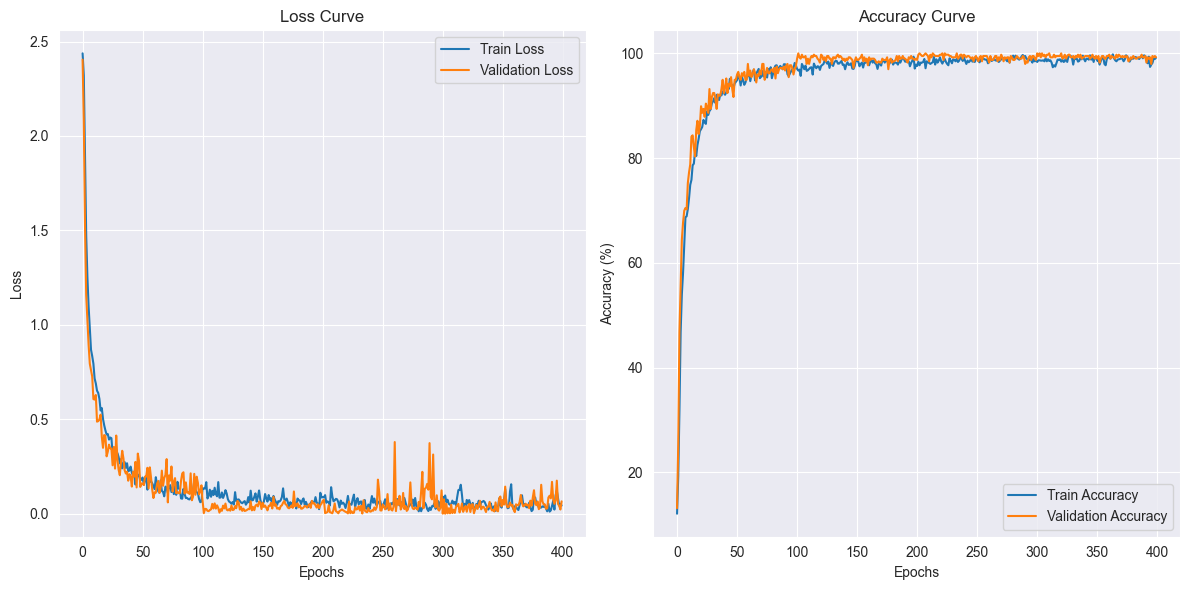

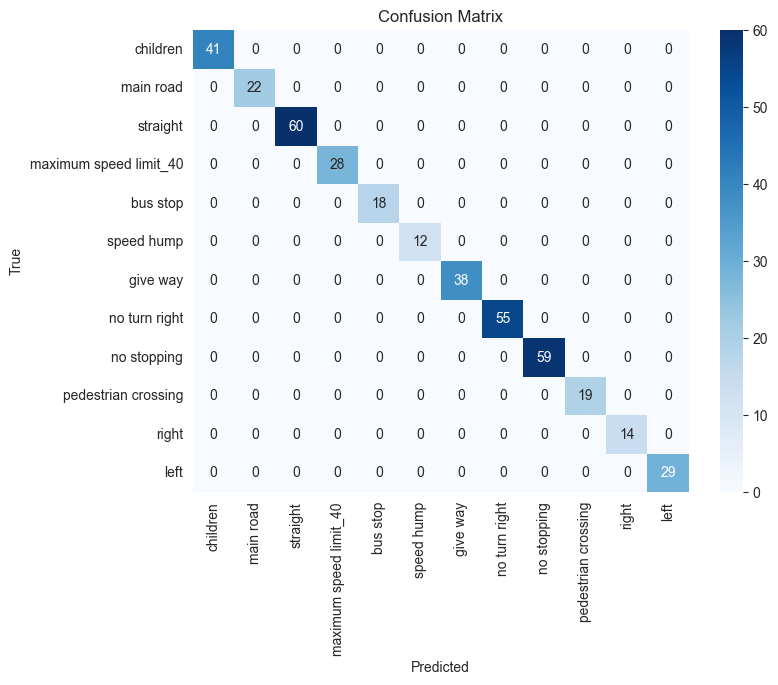

Test Loss: 0.2213, Test Accuracy: 97.60%
Fold 4 validation accuracy: 97.60%
Epoch 1/100 - Train Loss: 0.0696, Train Acc: 99.05% | Val Loss: 0.0119, Val Acc: 99.75% * Model saved
Epoch 2/100 - Train Loss: 0.1030, Train Acc: 97.98% | Val Loss: 0.0040, Val Acc: 99.75%
Epoch 3/100 - Train Loss: 0.0477, Train Acc: 98.80% | Val Loss: 0.0006, Val Acc: 100.00% * Model saved
Epoch 4/100 - Train Loss: 0.1040, Train Acc: 98.04% | Val Loss: 0.0276, Val Acc: 99.75%
Epoch 5/100 - Train Loss: 0.0949, Train Acc: 98.36% | Val Loss: 0.0037, Val Acc: 99.75%
Epoch 6/100 - Train Loss: 0.0805, Train Acc: 98.67% | Val Loss: 0.0027, Val Acc: 100.00%
Epoch 7/100 - Train Loss: 0.0295, Train Acc: 99.43% | Val Loss: 0.0026, Val Acc: 100.00%
Epoch 8/100 - Train Loss: 0.0309, Train Acc: 99.12% | Val Loss: 0.0004, Val Acc: 100.00%
Epoch 9/100 - Train Loss: 0.0508, Train Acc: 99.43% | Val Loss: 0.0009, Val Acc: 100.00%
Epoch 10/100 - Train Loss: 0.0614, Train Acc: 98.67% | Val Loss: 0.0126, Val Acc: 99.75%
Epoch 11/1

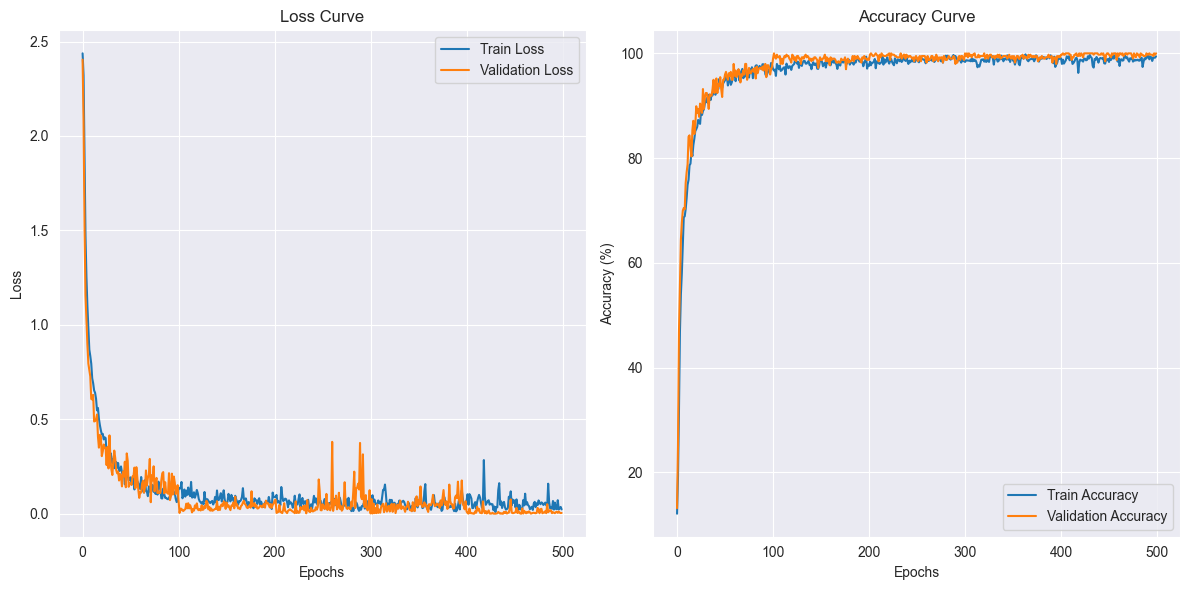

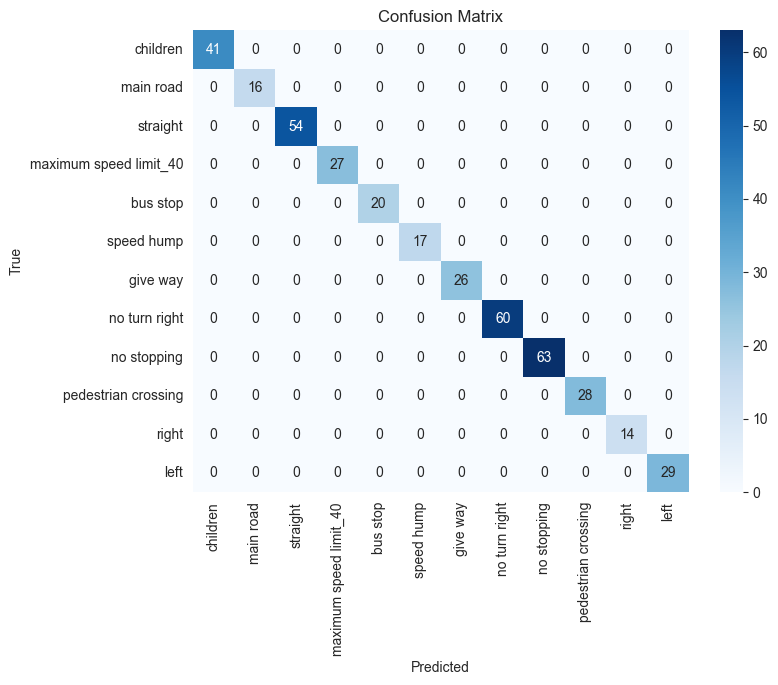

Test Loss: 0.2534, Test Accuracy: 96.39%
Fold 5 validation accuracy: 96.39%
Average validation accuracy for this parameter set: 96.83%


96.83366733466934

In [61]:
model = SignModel().to(device)
criterion = nn.CrossEntropyLoss()
k_fold_cross_validation(model, train_data, device, k=5, epochs=100)

In [62]:
evaluate_model(model, test_loader, criterion)

Test Loss: 0.2058, Test Accuracy: 96.59%


(0.20579626612369673, 96.59318637274549)

In [26]:
# # Define lists to store the metrics
# train_losses = []
# train_accuracies = []
# val_losses = []
# val_accuracies = []
# 
# train_model(model, train_loader, test_loader, optimizer, criterion, epochs=100, patience=50)

In [ ]:
# # Set up EarlyStopping functionality (similar to Keras' EarlyStopping)
# from torch.utils.data import DataLoader
# 
# 
# class EarlyStopping:
#     def __init__(self, patience=10, verbose=False, delta=0):
#         self.patience = patience
#         self.verbose = verbose
#         self.delta = delta
#         self.counter = 0
#         self.best_loss = np.inf
#         self.early_stop = False
# 
#     def __call__(self, val_loss, model):
#         if val_loss < self.best_loss - self.delta:
#             self.best_loss = val_loss
#             self.counter = 0
#         else:
#             self.counter += 1
#             if self.counter >= self.patience:
#                 self.early_stop = True
# 
#         if self.verbose and self.early_stop:
#             print(f"Early stopping triggered after {self.counter} epochs.")
#         return self.early_stop
# 


Model saved with new best validation accuracy: 47.21%
Epoch 1/120 - Train Loss: 2.3543, Train Acc: 45.79% | Val Loss: 2.2942, Val Acc: 47.21%
Epoch 2/120 - Train Loss: 2.1493, Train Acc: 47.96% | Val Loss: 2.2245, Val Acc: 47.21%
Model saved with new best validation accuracy: 48.55%
Epoch 3/120 - Train Loss: 2.0262, Train Acc: 48.55% | Val Loss: 2.0917, Val Acc: 48.55%
Model saved with new best validation accuracy: 54.34%
Epoch 4/120 - Train Loss: 1.8875, Train Acc: 50.96% | Val Loss: 1.8617, Val Acc: 54.34%
Model saved with new best validation accuracy: 54.91%
Epoch 5/120 - Train Loss: 1.6996, Train Acc: 54.85% | Val Loss: 1.7974, Val Acc: 54.91%
Model saved with new best validation accuracy: 57.80%
Epoch 6/120 - Train Loss: 1.6124, Train Acc: 57.07% | Val Loss: 1.5976, Val Acc: 57.80%
Model saved with new best validation accuracy: 59.92%
Epoch 7/120 - Train Loss: 1.4718, Train Acc: 60.12% | Val Loss: 1.4816, Val Acc: 59.92%
Model saved with new best validation accuracy: 61.85%
Epoch 

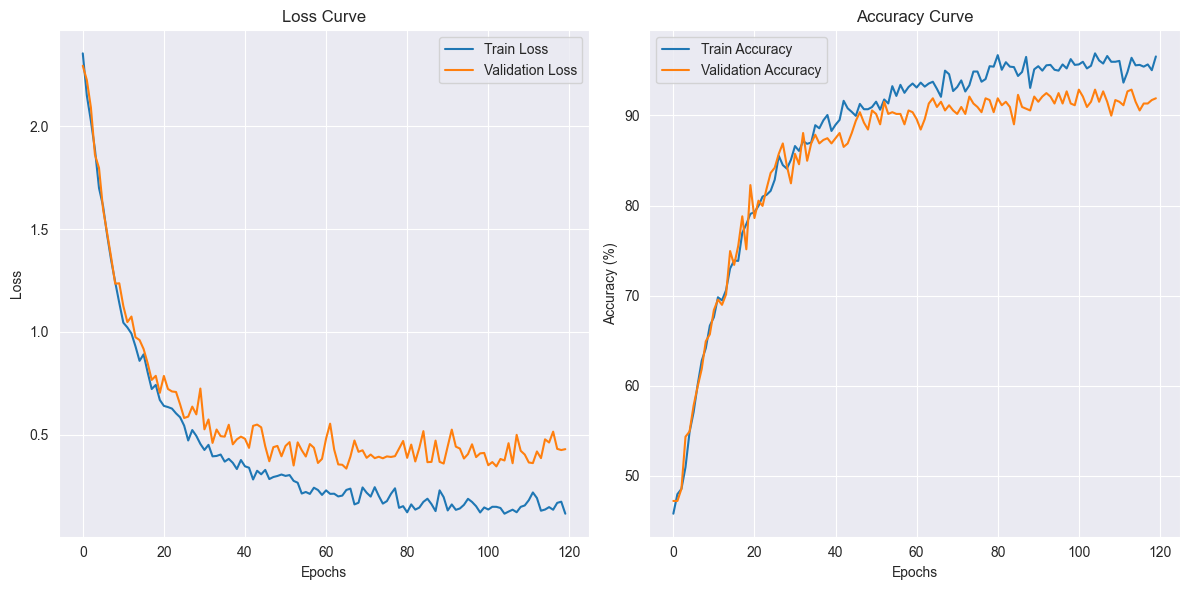

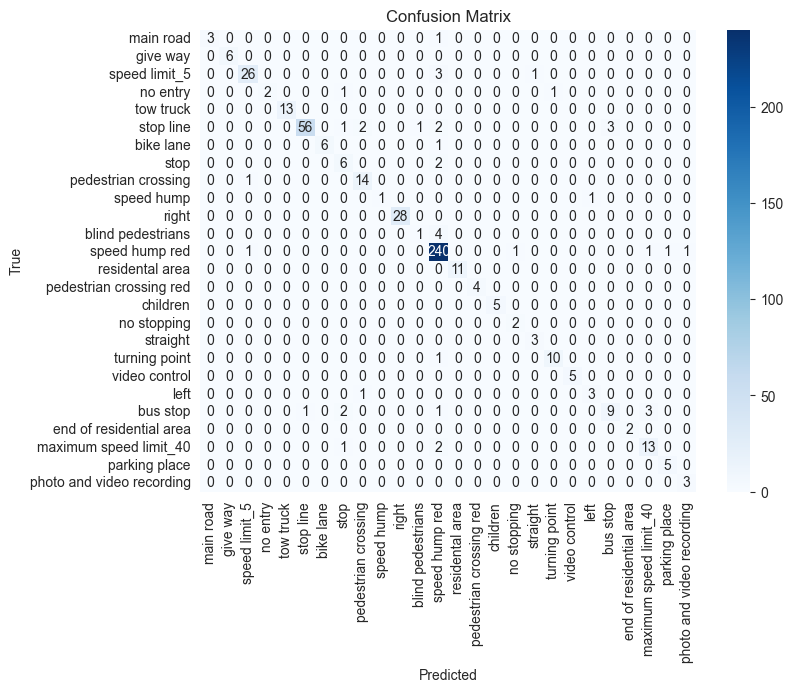

In [49]:
train_and_evaluate(model, train_loader, test_loader, criterion, 120, device)

Model saved with new best validation accuracy: 91.71%
Epoch 1/30 - Train Loss: 0.1910, Train Acc: 95.08% | Val Loss: 0.4146, Val Acc: 91.71%
Epoch 2/30 - Train Loss: 0.1767, Train Acc: 94.93% | Val Loss: 0.5199, Val Acc: 89.98%
Epoch 3/30 - Train Loss: 0.2136, Train Acc: 94.58% | Val Loss: 0.5260, Val Acc: 91.71%
Epoch 4/30 - Train Loss: 0.1368, Train Acc: 96.21% | Val Loss: 0.5733, Val Acc: 91.33%
Model saved with new best validation accuracy: 91.91%
Epoch 5/30 - Train Loss: 0.1065, Train Acc: 96.90% | Val Loss: 0.4549, Val Acc: 91.91%
Epoch 6/30 - Train Loss: 0.1826, Train Acc: 95.03% | Val Loss: 0.5169, Val Acc: 89.02%
Epoch 7/30 - Train Loss: 0.1615, Train Acc: 95.91% | Val Loss: 0.4098, Val Acc: 90.75%
Epoch 8/30 - Train Loss: 0.1523, Train Acc: 95.72% | Val Loss: 0.4497, Val Acc: 91.14%
Epoch 9/30 - Train Loss: 0.1505, Train Acc: 95.62% | Val Loss: 0.4783, Val Acc: 91.52%
Epoch 10/30 - Train Loss: 0.1371, Train Acc: 96.11% | Val Loss: 0.4224, Val Acc: 91.91%
Epoch 11/30 - Train L

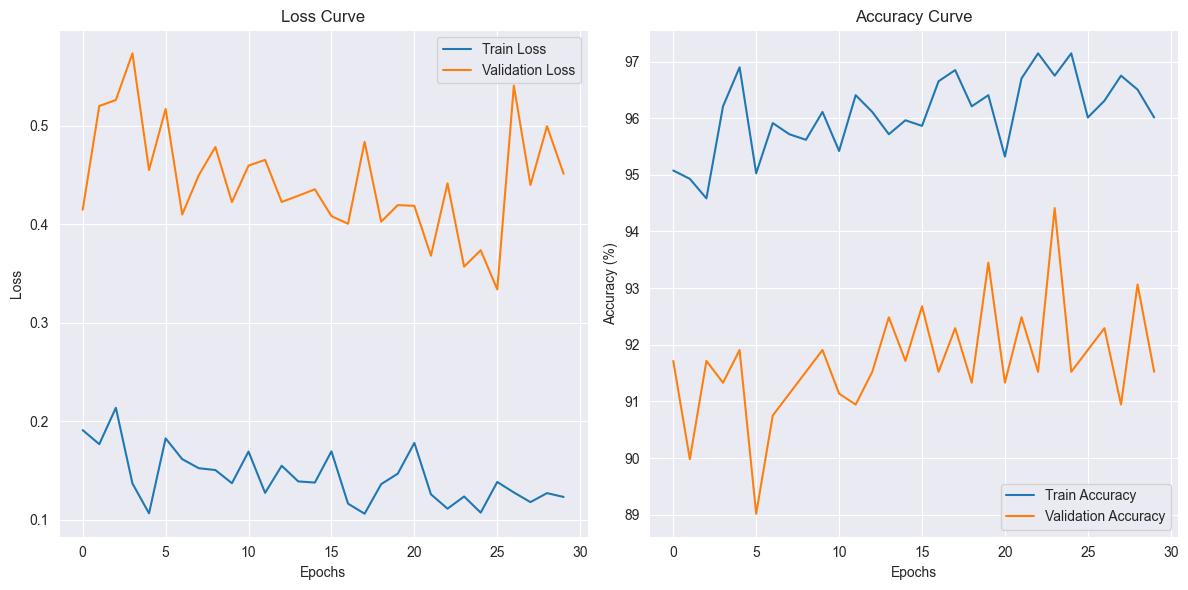

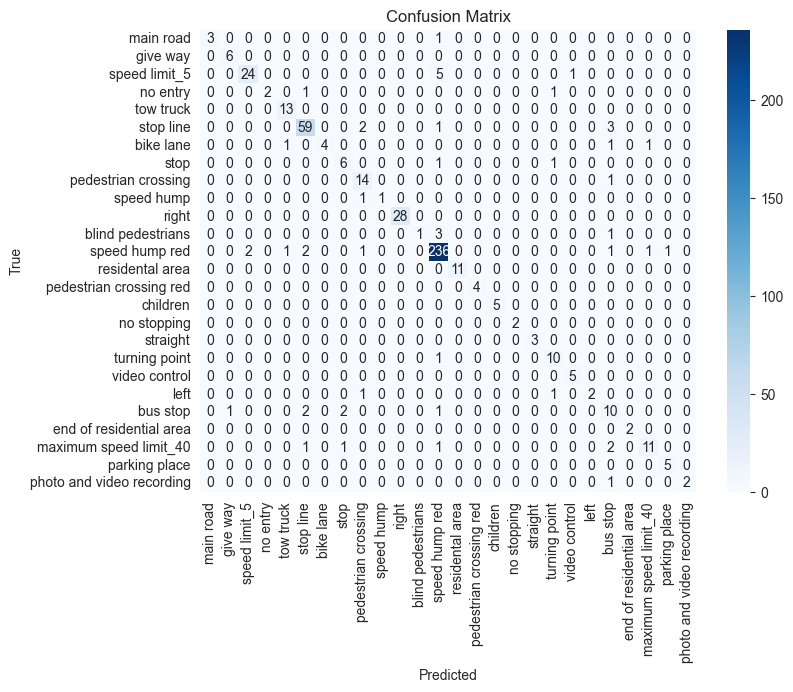

In [51]:
train_and_evaluate(model, train_loader, test_loader, criterion, 30, device)

In [26]:
# Loading best model
# model1 = SignModelUpgraded().to(device)

# Load the best model's weights
state_dict = torch.load('best_model98.pth')  # Загружаем веса (они в формате OrderedDict)
model.load_state_dict(state_dict) 
# 3. Сохраняем полную модель
torch.save(model, 'best_model 97-39 2HL.pth')  # Сохраняем модель, включая архитектуру и веса



AttributeError: 'collections.OrderedDict' object has no attribute 'load_state_dict'

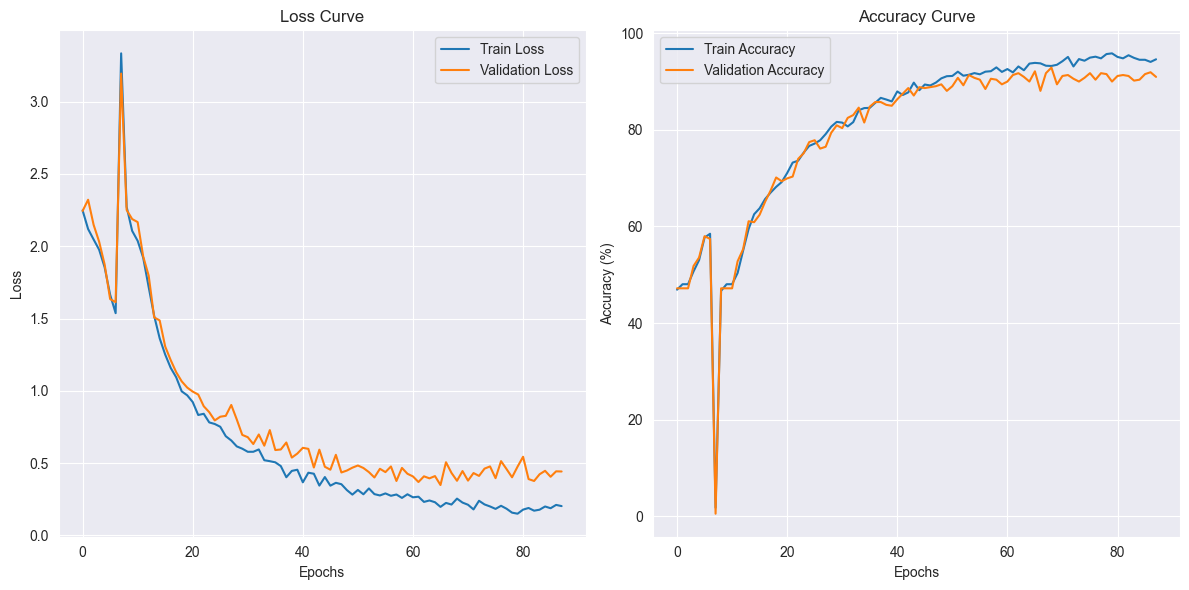

In [36]:
plot_learning_curves(train_losses[200:], val_losses[200:], train_accuracies[200:], val_accuracies[200:])